In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

In [19]:
# Set visualization style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("talk")

In [20]:
# Load the dataset
df = pd.read_csv('../data/processed/integrated_all_columns.csv')

# Convert is_gentrified to boolean
df['is_gentrified'] = df['is_gentrified'].astype(bool)

In [21]:
# Verify conversion
print(f"Gentrified: {df['is_gentrified'].sum()} ({df['is_gentrified'].mean()*100:.2f}%)")
print(f"Not Gentrified: {(~df['is_gentrified']).sum()} ({(~df['is_gentrified']).mean()*100:.2f}%)")

Gentrified: 127 (45.52%)
Not Gentrified: 152 (54.48%)


In [22]:
# Extract all business type features (those starting with 'ttl_') and price levels
business_features = [col for col in df.columns if col.startswith('ttl_')]
price_features = ['EXPENSIVE', 'MODERATE', 'INEXPENSIVE']
all_features = business_features + price_features

print(f"Number of business features: {len(business_features)}")
print(f"Total features for analysis: {len(all_features)}")

Number of business features: 126
Total features for analysis: 129


In [23]:
# Split data into training and testing sets
train, test = train_test_split(df, test_size=0.3, random_state=42, stratify=df['is_gentrified'])

# Prepare feature matrices and target vectors
X_train = train[all_features].values
y_train = train['is_gentrified'].astype(int).values
X_test = test[all_features].values
y_test = test['is_gentrified'].astype(int).values

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set: {X_train_scaled.shape}")
print(f"Test set: {X_test_scaled.shape}")

Training set: (195, 129)
Test set: (84, 129)


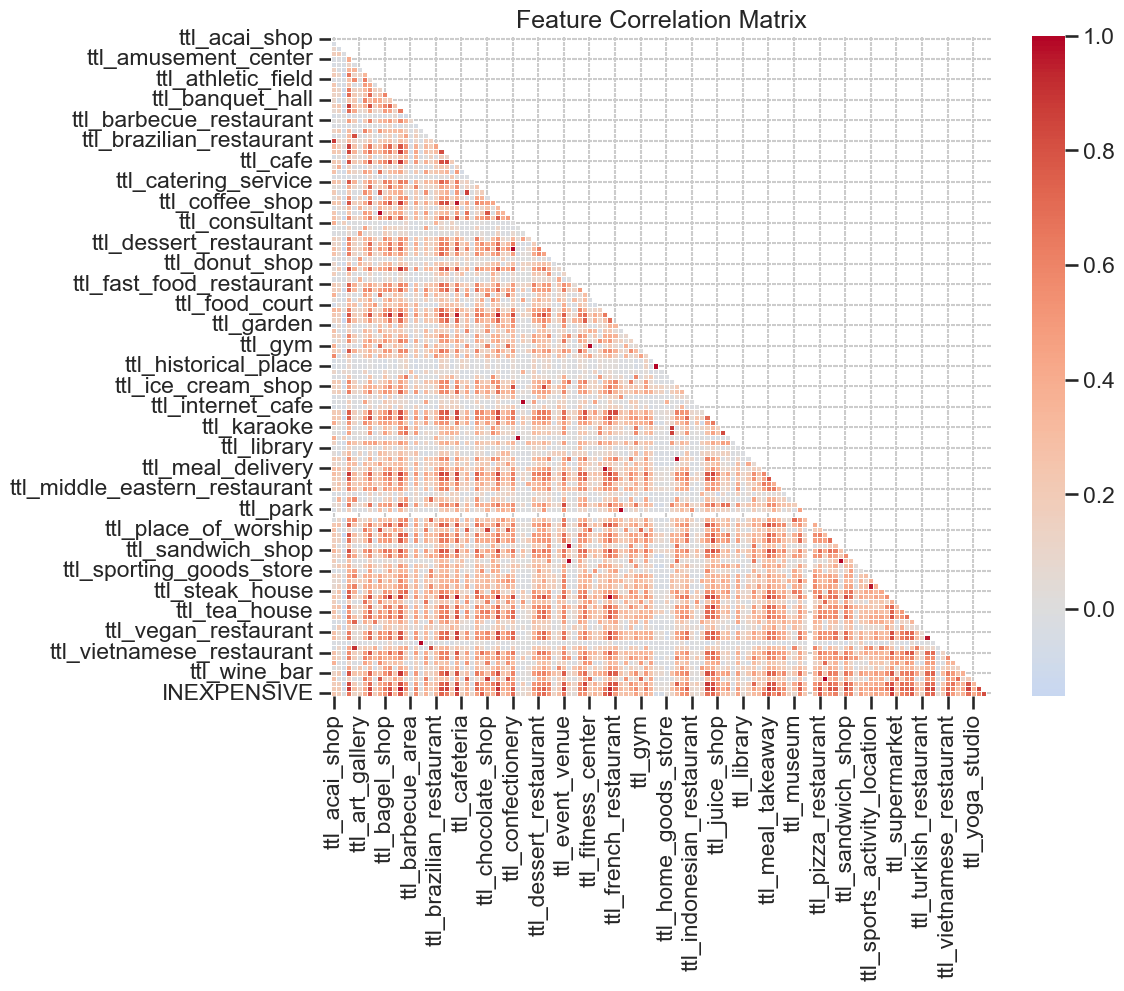

In [24]:
# Check for feature correlations
plt.figure(figsize=(12, 10))
correlation_matrix = train[all_features].corr()
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
sns.heatmap(correlation_matrix, mask=mask, cmap="coolwarm", 
            center=0, square=True, linewidths=.5)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

### pca

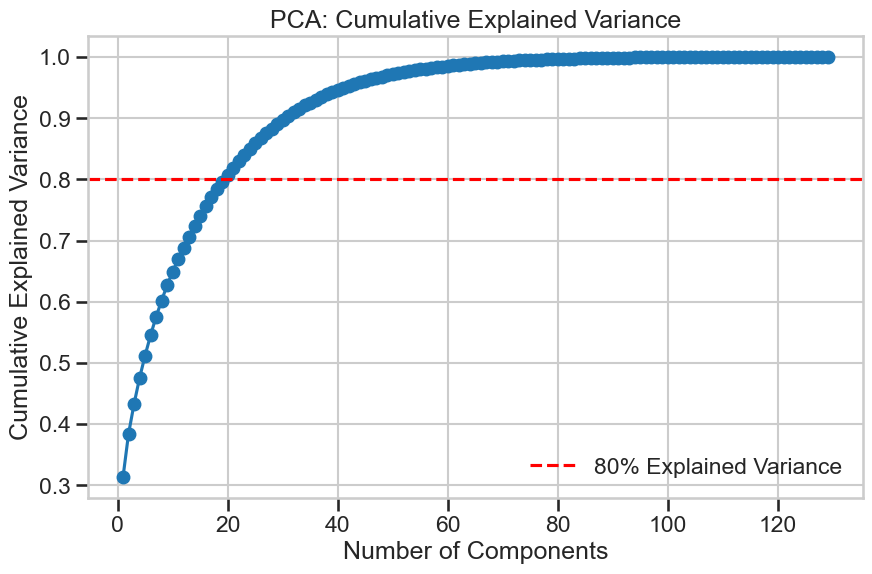

In [25]:
# Determine optimal number of components for PCA
pca_full = PCA()
pca_full.fit(X_train_scaled)

# Plot explained variance ratio
plt.figure(figsize=(10, 6))
cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, 'o-')
plt.axhline(y=0.8, color='r', linestyle='--', label='80% Explained Variance')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA: Cumulative Explained Variance')
plt.legend()
plt.grid(True)
plt.show()

In [26]:
# Find number of components needed for 80% variance
n_components = np.argmax(cumulative_variance >= 0.8) + 1
print(f"Number of components needed for 80% explained variance: {n_components}")

# Perform PCA with optimal number of components
pca = PCA(n_components=n_components)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

# Create a DataFrame with principal components for easier analysis
pca_df = pd.DataFrame(
    data=X_train_pca,
    columns=[f'PC{i+1}' for i in range(n_components)]
)
pca_df['is_gentrified'] = y_train

Number of components needed for 80% explained variance: 20


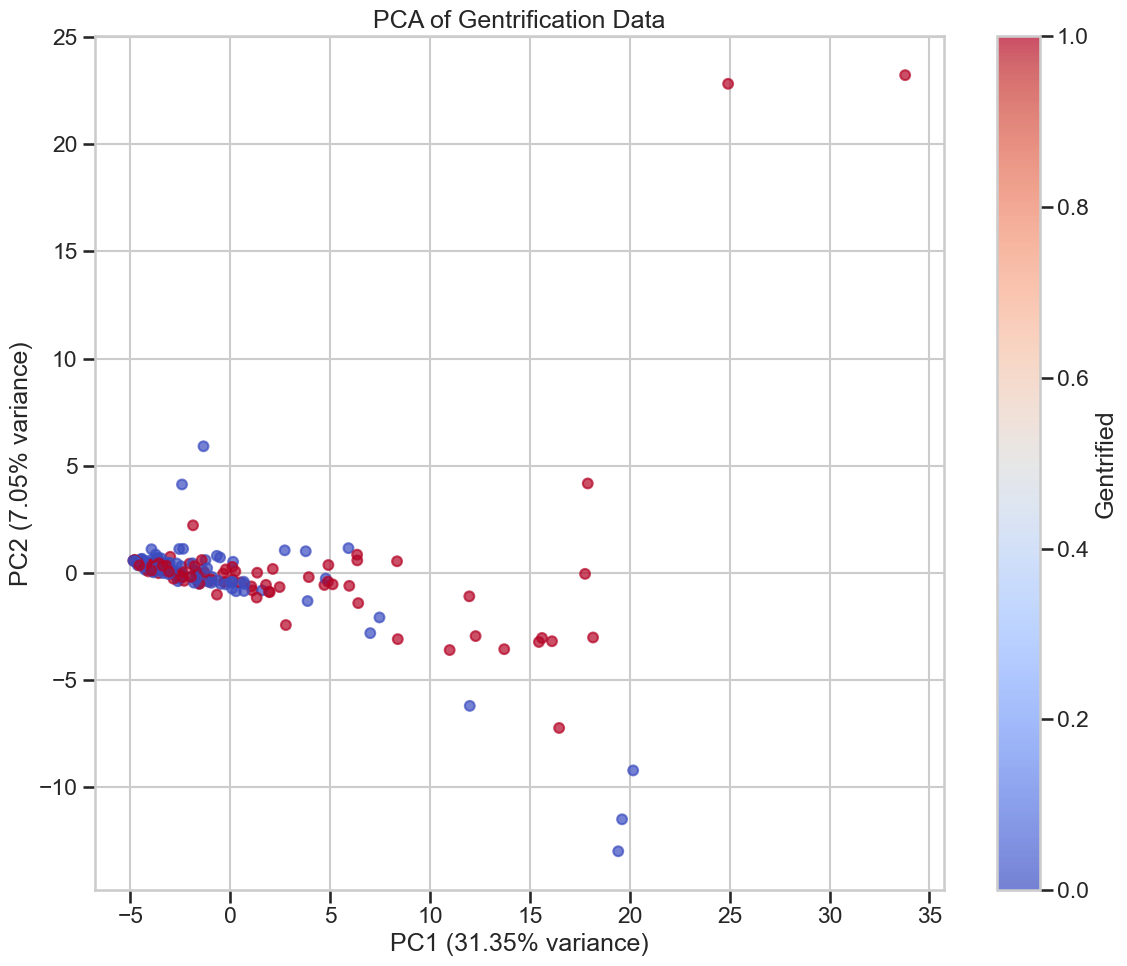

In [27]:
# Visualize the first two principal components
plt.figure(figsize=(12, 10))
scatter = plt.scatter(
    pca_df['PC1'], 
    pca_df['PC2'], 
    c=pca_df['is_gentrified'],
    cmap=plt.cm.coolwarm, 
    alpha=0.7, 
    s=50
)
plt.colorbar(scatter, label='Gentrified')
plt.xlabel(f'PC1 ({pca_full.explained_variance_ratio_[0]:.2%} variance)')
plt.ylabel(f'PC2 ({pca_full.explained_variance_ratio_[1]:.2%} variance)')
plt.title('PCA of Gentrification Data')
plt.grid(True)
plt.tight_layout()
plt.show()

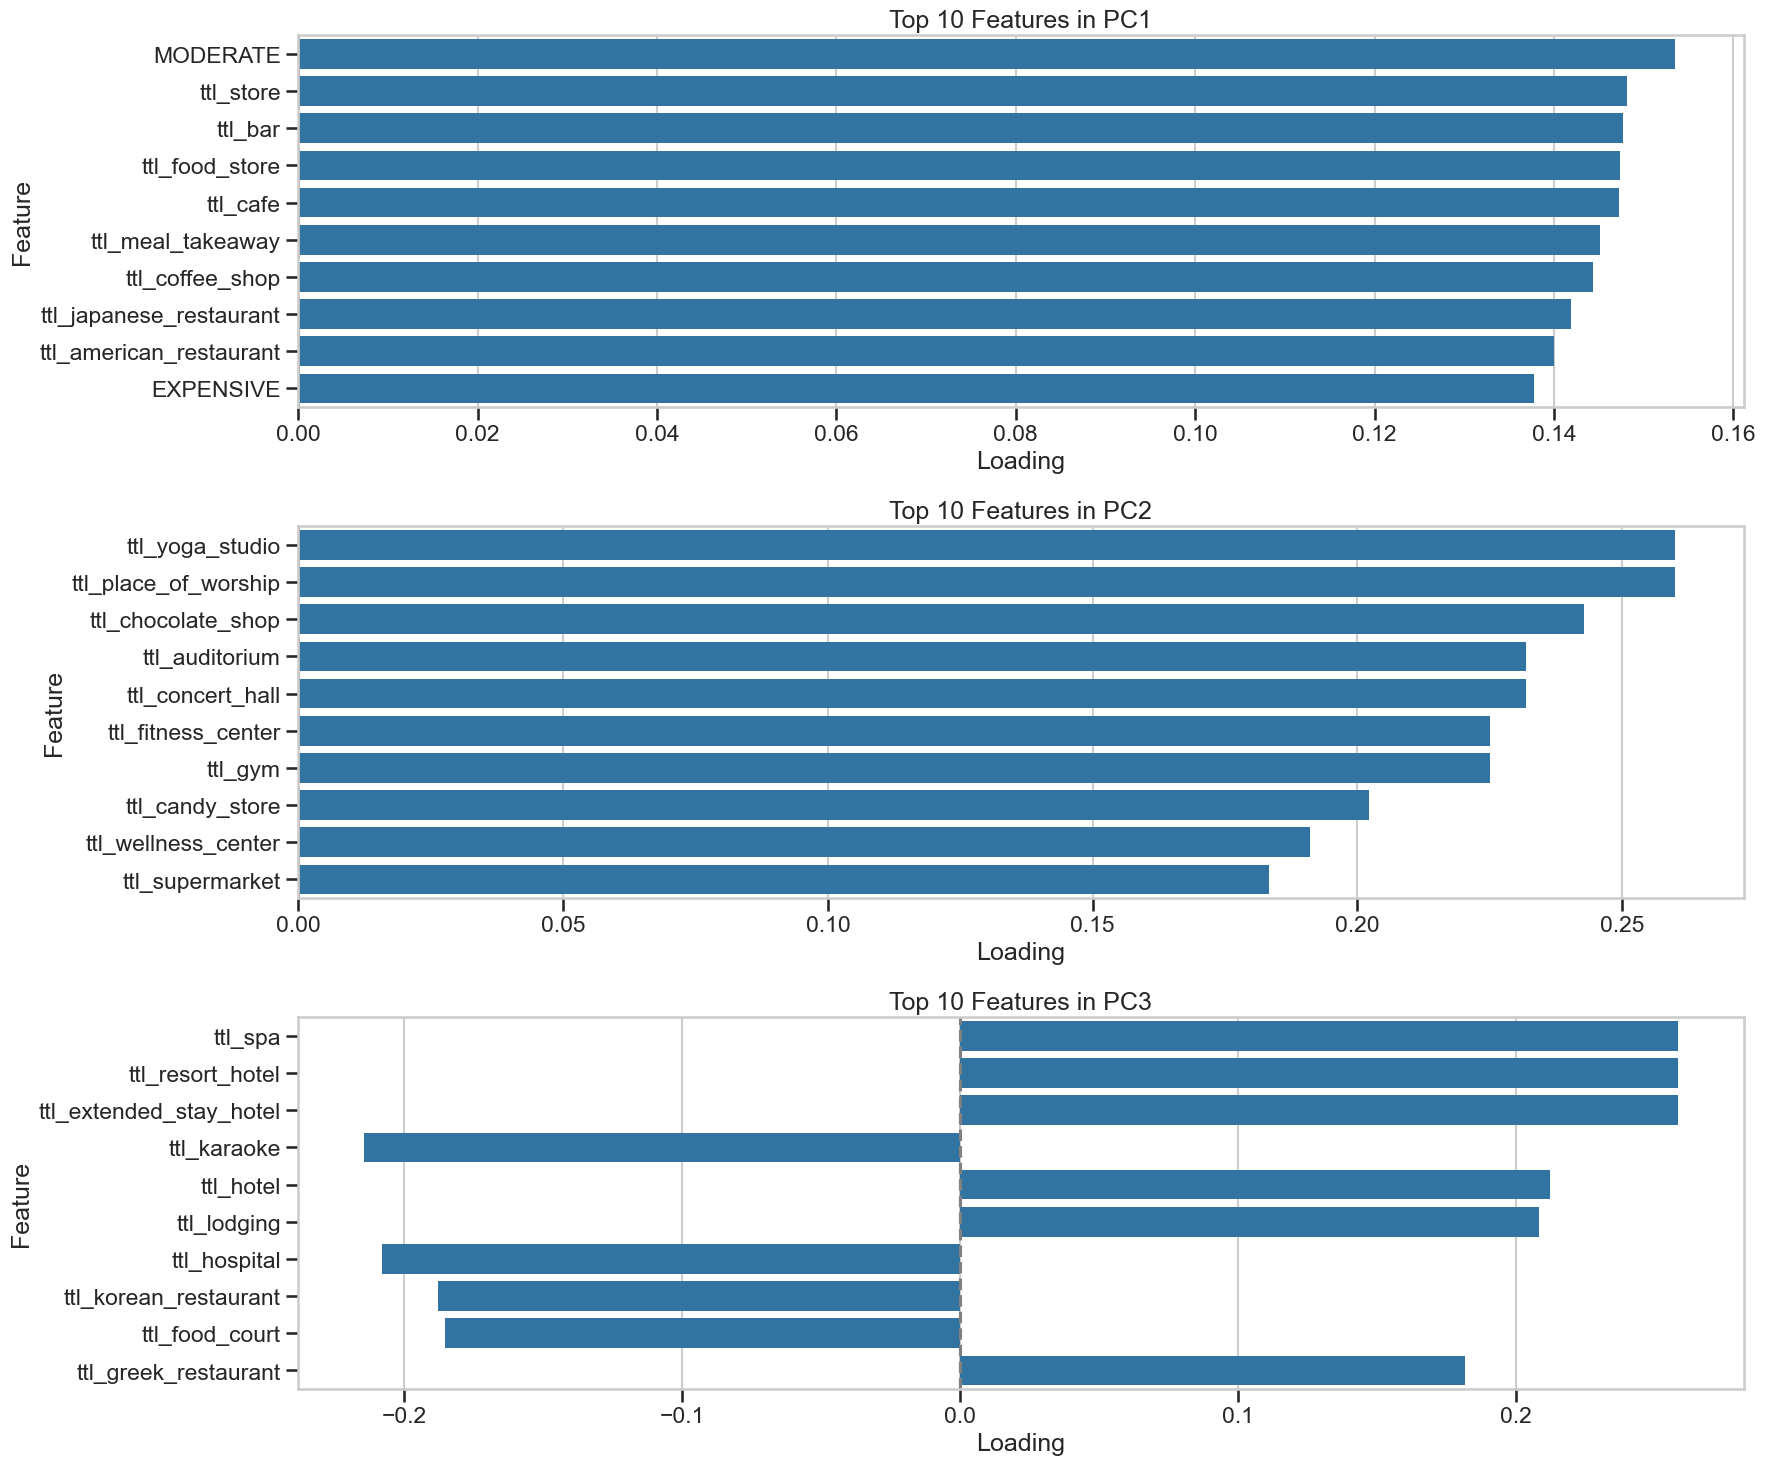

In [28]:
# Get feature loadings for the first few components
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f'PC{i+1}' for i in range(n_components)],
    index=all_features
)

# Show the top contributing features to the first 3 PCs
n_top = 10
plt.figure(figsize=(18, 15))

for i in range(3):  # First 3 components
    plt.subplot(3, 1, i+1)
    
    # Sort loadings by absolute value
    pc_loadings = loadings[f'PC{i+1}'].abs().sort_values(ascending=False)
    top_features = pc_loadings.head(n_top).index
    
    # Plot horizontal bar chart
    sns.barplot(x=loadings.loc[top_features, f'PC{i+1}'], y=top_features)
    plt.title(f'Top {n_top} Features in PC{i+1}')
    plt.xlabel('Loading')
    plt.ylabel('Feature')
    plt.axvline(x=0, color='gray', linestyle='--')
    
plt.tight_layout()
plt.show()

For n_clusters = 2, the silhouette score is 0.6789
For n_clusters = 3, the silhouette score is 0.6362
For n_clusters = 4, the silhouette score is 0.4260
For n_clusters = 5, the silhouette score is 0.4502
For n_clusters = 6, the silhouette score is 0.4358
For n_clusters = 7, the silhouette score is 0.4393
For n_clusters = 8, the silhouette score is 0.4410
For n_clusters = 9, the silhouette score is 0.4478


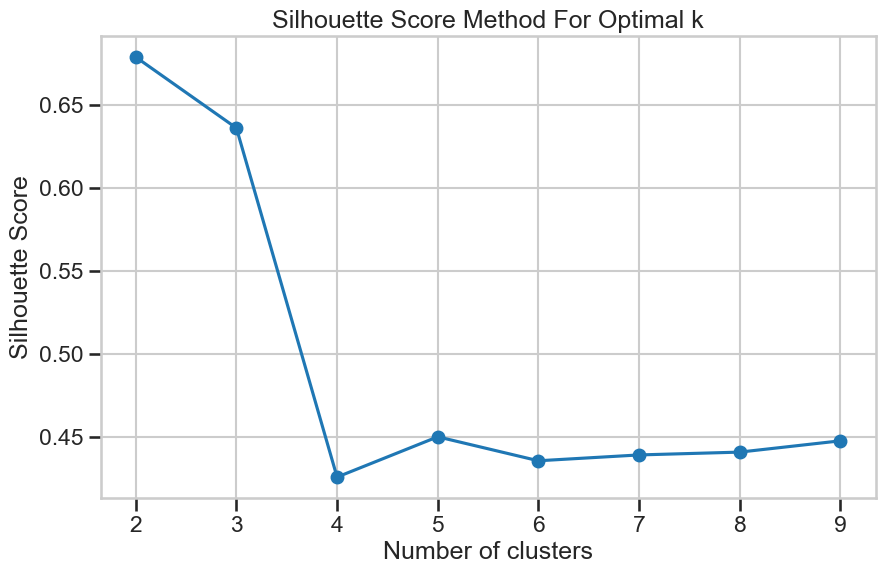

Optimal number of clusters: 2


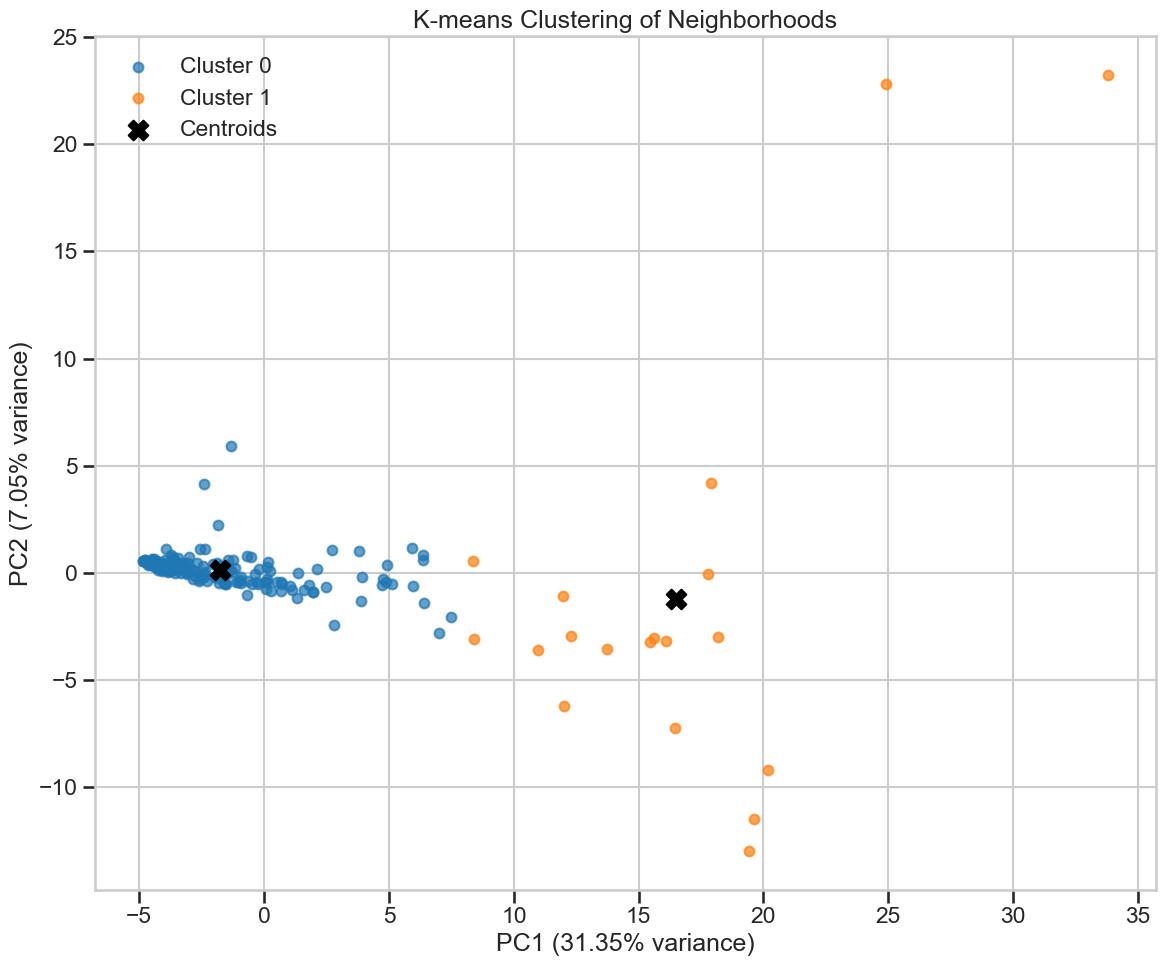

In [29]:
# Find optimal number of clusters using silhouette score
silhouette_scores = []
range_n_clusters = range(2, 10)

for n_clusters in range_n_clusters:
    clusterer = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    cluster_labels = clusterer.fit_predict(X_train_pca)
    silhouette_avg = silhouette_score(X_train_pca, cluster_labels)
    silhouette_scores.append(silhouette_avg)
    print(f"For n_clusters = {n_clusters}, the silhouette score is {silhouette_avg:.4f}")

# Plot silhouette scores
plt.figure(figsize=(10, 6))
plt.plot(range_n_clusters, silhouette_scores, 'o-')
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score Method For Optimal k')
plt.grid(True)
plt.show()

# Get optimal number of clusters
optimal_clusters = range_n_clusters[np.argmax(silhouette_scores)]
print(f"Optimal number of clusters: {optimal_clusters}")

# Perform K-means clustering with optimal clusters
kmeans = KMeans(n_clusters=optimal_clusters, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_train_pca)

# Add cluster labels to the PCA dataframe
pca_df['Cluster'] = clusters

# Visualize clusters on PCA plot
plt.figure(figsize=(12, 10))
for cluster in range(optimal_clusters):
    cluster_data = pca_df[pca_df['Cluster'] == cluster]
    plt.scatter(
        cluster_data['PC1'], 
        cluster_data['PC2'],
        label=f'Cluster {cluster}',
        alpha=0.7,
        s=50
    )

# Add centroids
centroids_pca = kmeans.cluster_centers_
plt.scatter(
    centroids_pca[:, 0], 
    centroids_pca[:, 1],
    marker='X', 
    s=200, 
    c='black', 
    label='Centroids'
)

plt.xlabel(f'PC1 ({pca_full.explained_variance_ratio_[0]:.2%} variance)')
plt.ylabel(f'PC2 ({pca_full.explained_variance_ratio_[1]:.2%} variance)')
plt.title('K-means Clustering of Neighborhoods')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

         Gentrification %  Count
Cluster                         
1               78.947368     19
0               42.045455    176


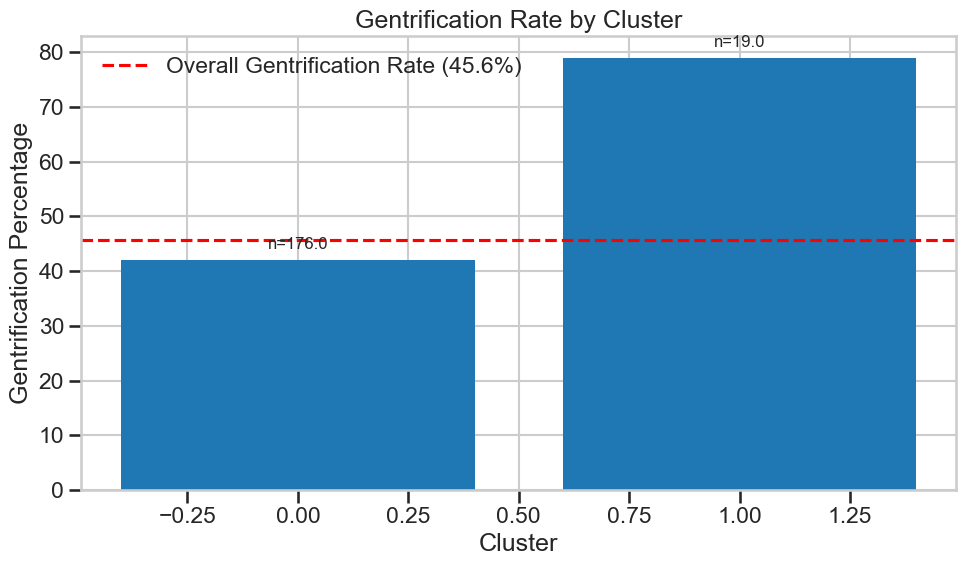

In [30]:
# Create a dataframe with cluster assignments
train_with_clusters = train.copy()
train_with_clusters['Cluster'] = clusters

# Calculate percentage of gentrified neighborhoods in each cluster
cluster_gentrification = train_with_clusters.groupby('Cluster')['is_gentrified'].agg(['mean', 'count'])
cluster_gentrification['mean'] = cluster_gentrification['mean'] * 100  # Convert to percentage
cluster_gentrification = cluster_gentrification.rename(columns={'mean': 'Gentrification %', 'count': 'Count'})
cluster_gentrification = cluster_gentrification.sort_values('Gentrification %', ascending=False)

print(cluster_gentrification)

# Visualize gentrification percentage by cluster
plt.figure(figsize=(10, 6))
bars = plt.bar(cluster_gentrification.index, cluster_gentrification['Gentrification %'])

# Add count labels
for i, bar in enumerate(bars):
    count = cluster_gentrification.iloc[i]['Count']
    plt.text(bar.get_x() + bar.get_width()/2, 
             bar.get_height() + 2, 
             f"n={count}", 
             ha='center', fontsize=12)

plt.axhline(y=y_train.mean()*100, color='red', linestyle='--', 
           label=f'Overall Gentrification Rate ({y_train.mean()*100:.1f}%)')
plt.xlabel('Cluster')
plt.ylabel('Gentrification Percentage')
plt.title('Gentrification Rate by Cluster')
plt.legend()
plt.grid(True, axis='y')
plt.tight_layout()
plt.show()

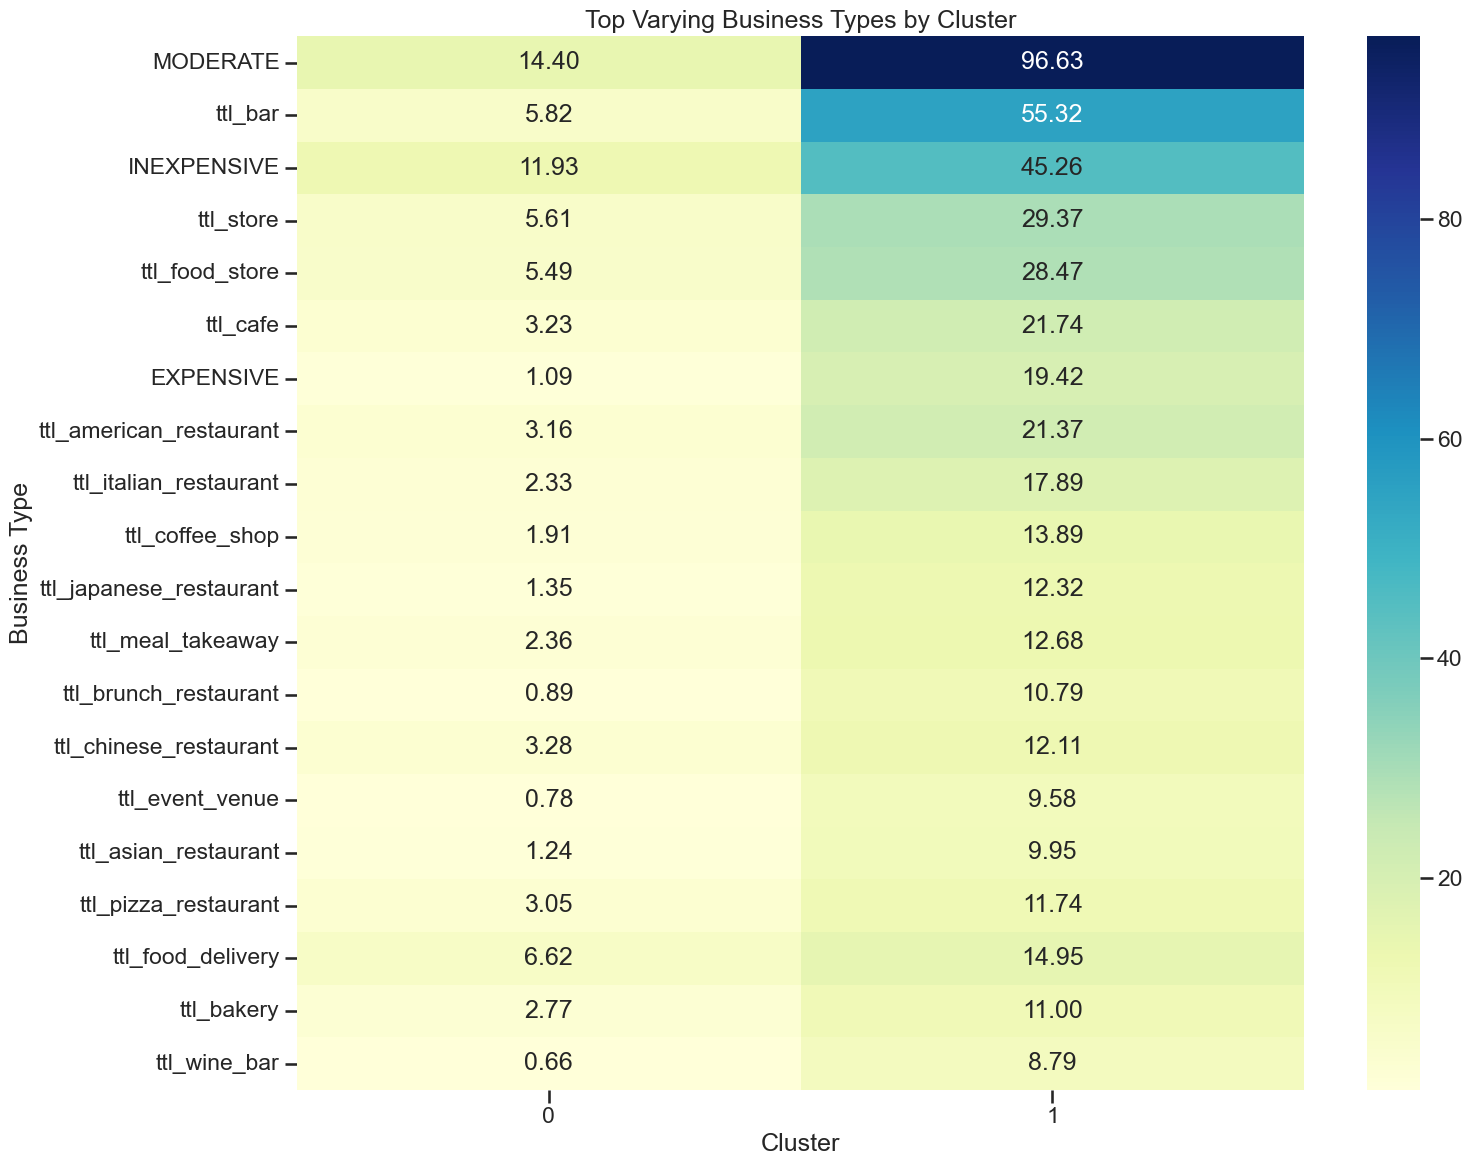

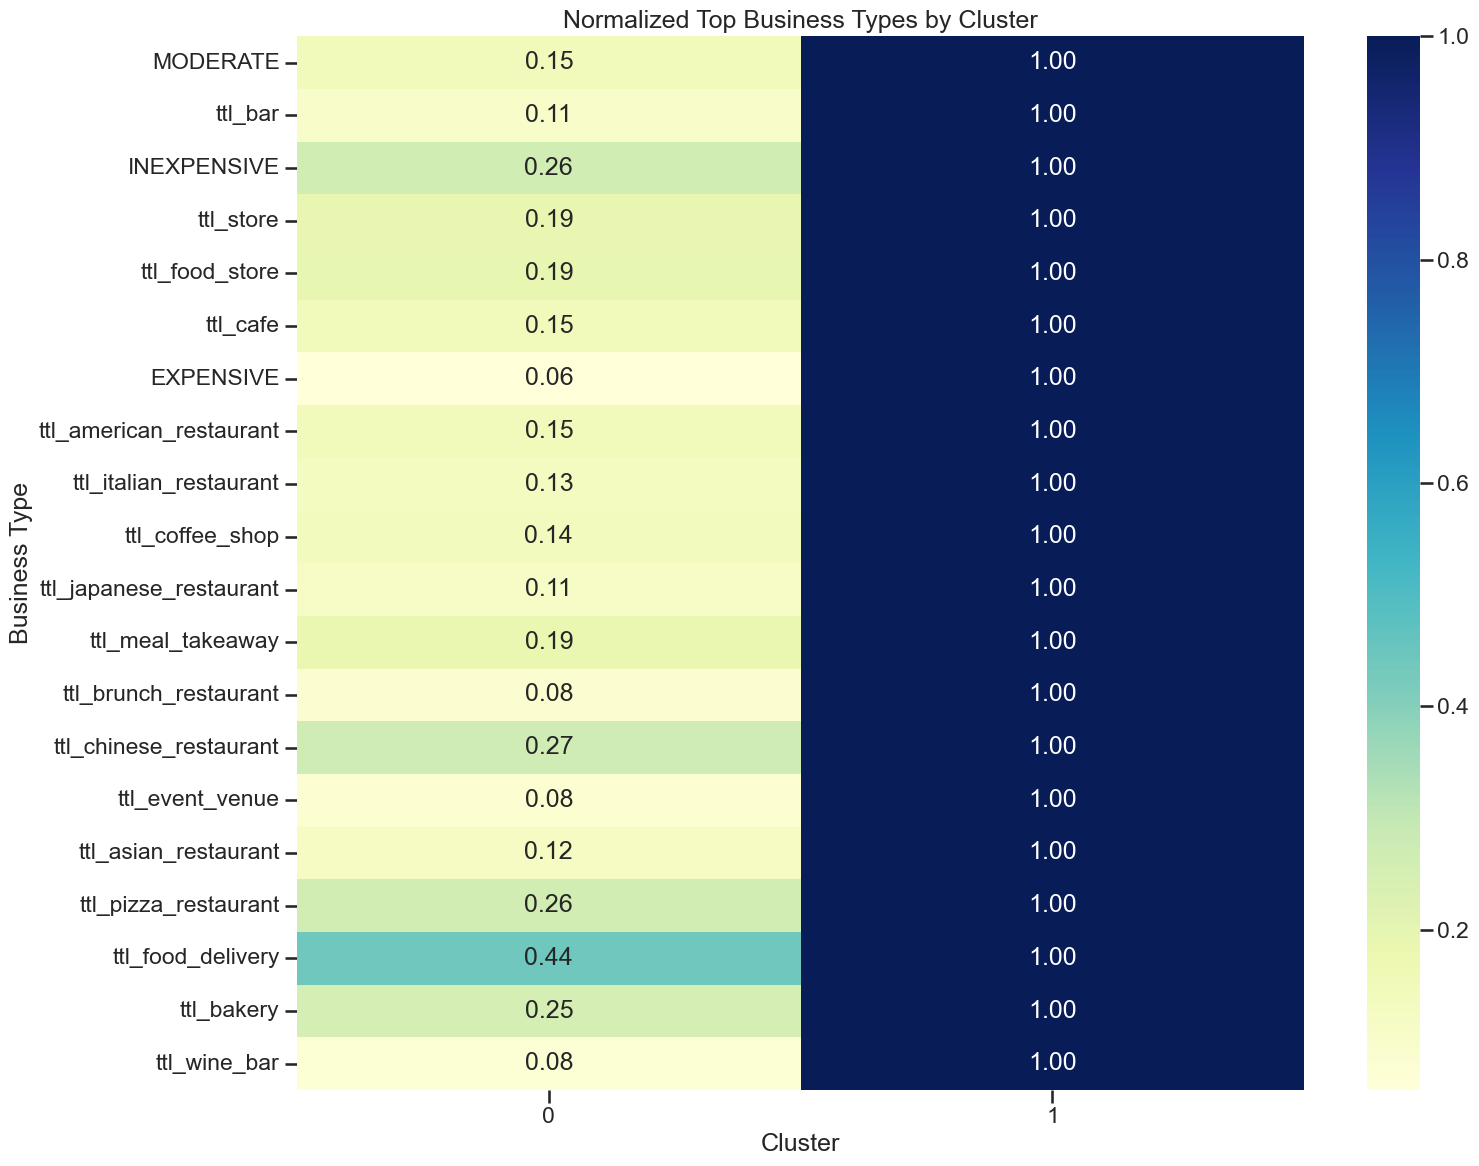

In [31]:
# Calculate mean business features for each cluster
cluster_profiles = train_with_clusters.groupby('Cluster')[all_features].mean()

# Get top 20 features with highest variance across clusters
variance_by_feature = cluster_profiles.var().sort_values(ascending=False)
top_varying_features = variance_by_feature.head(20).index.tolist()

# Create heatmap of top varying features across clusters
plt.figure(figsize=(16, 12))
sns.heatmap(
    cluster_profiles[top_varying_features].T,
    cmap='YlGnBu',
    annot=True,
    fmt='.2f'
)
plt.title('Top Varying Business Types by Cluster')
plt.ylabel('Business Type')
plt.xlabel('Cluster')
plt.tight_layout()
plt.show()

# Let's also create a normalized version for easier comparison
normalized_profiles = cluster_profiles.div(cluster_profiles.max())
plt.figure(figsize=(16, 12))
sns.heatmap(
    normalized_profiles[top_varying_features].T,
    cmap='YlGnBu',
    annot=True,
    fmt='.2f'
)
plt.title('Normalized Top Business Types by Cluster')
plt.ylabel('Business Type')
plt.xlabel('Cluster')
plt.tight_layout()
plt.show()


Random Forest Performance (using 20 PCA components):
Accuracy: 0.7500
Precision: 0.6977
Recall: 0.7895
F1 Score: 0.7407


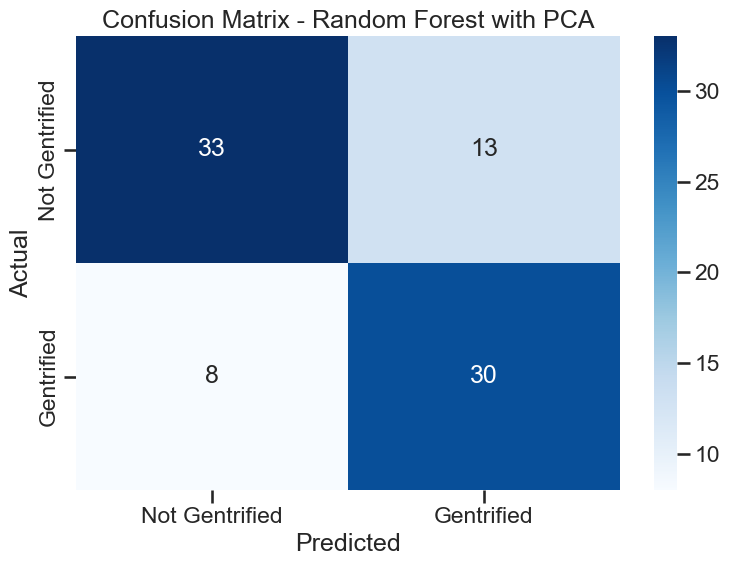

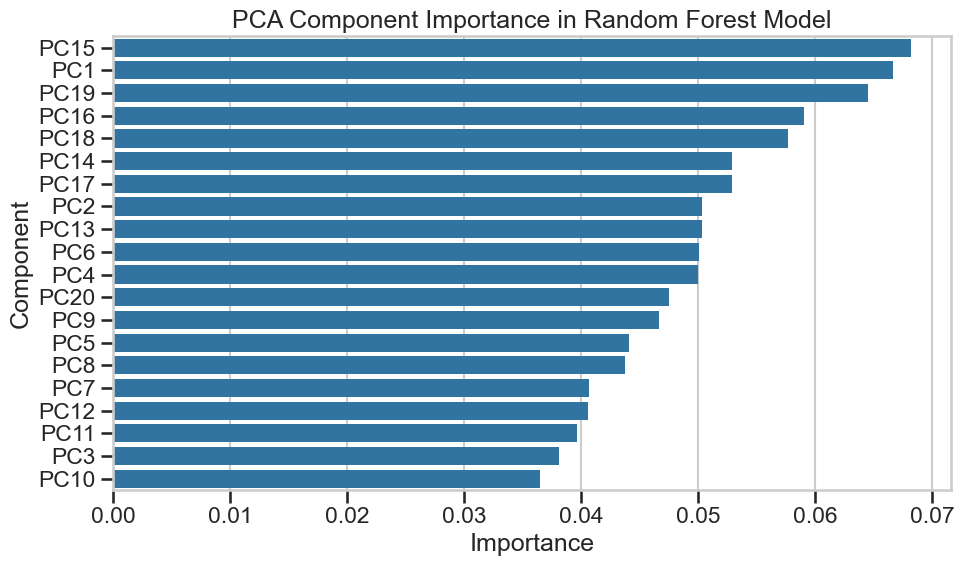


Random Forest Performance (using all original features):
Accuracy: 0.8095
F1 Score: 0.7895

Difference (Original - PCA):
Accuracy: 0.0595
F1 Score: 0.0487


In [32]:
# Train a Random Forest model on the PCA components
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_pca, y_train)

# Make predictions
y_pred = rf_model.predict(X_test_pca)

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"\nRandom Forest Performance (using {n_components} PCA components):")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

# Plot confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
           xticklabels=['Not Gentrified', 'Gentrified'],
           yticklabels=['Not Gentrified', 'Gentrified'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Random Forest with PCA')
plt.tight_layout()
plt.show()

# Feature importance based on PCA components
feature_importance = pd.DataFrame({
    'Component': [f'PC{i+1}' for i in range(n_components)],
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Component', data=feature_importance)
plt.title('PCA Component Importance in Random Forest Model')
plt.tight_layout()
plt.show()

# For completeness, train a model on the original features for comparison
rf_original = RandomForestClassifier(n_estimators=100, random_state=42)
rf_original.fit(X_train_scaled, y_train)
y_pred_original = rf_original.predict(X_test_scaled)

accuracy_original = accuracy_score(y_test, y_pred_original)
f1_original = f1_score(y_test, y_pred_original)

print(f"\nRandom Forest Performance (using all original features):")
print(f"Accuracy: {accuracy_original:.4f}")
print(f"F1 Score: {f1_original:.4f}")

# Compare with PCA model
print(f"\nDifference (Original - PCA):")
print(f"Accuracy: {accuracy_original - accuracy:.4f}")
print(f"F1 Score: {f1_original - f1:.4f}")

Component importance in Random Forest model:
  Component  Importance
0       PC1    0.126822
1       PC2    0.109577
3       PC4    0.109247
7       PC8    0.108068
8       PC9    0.100902


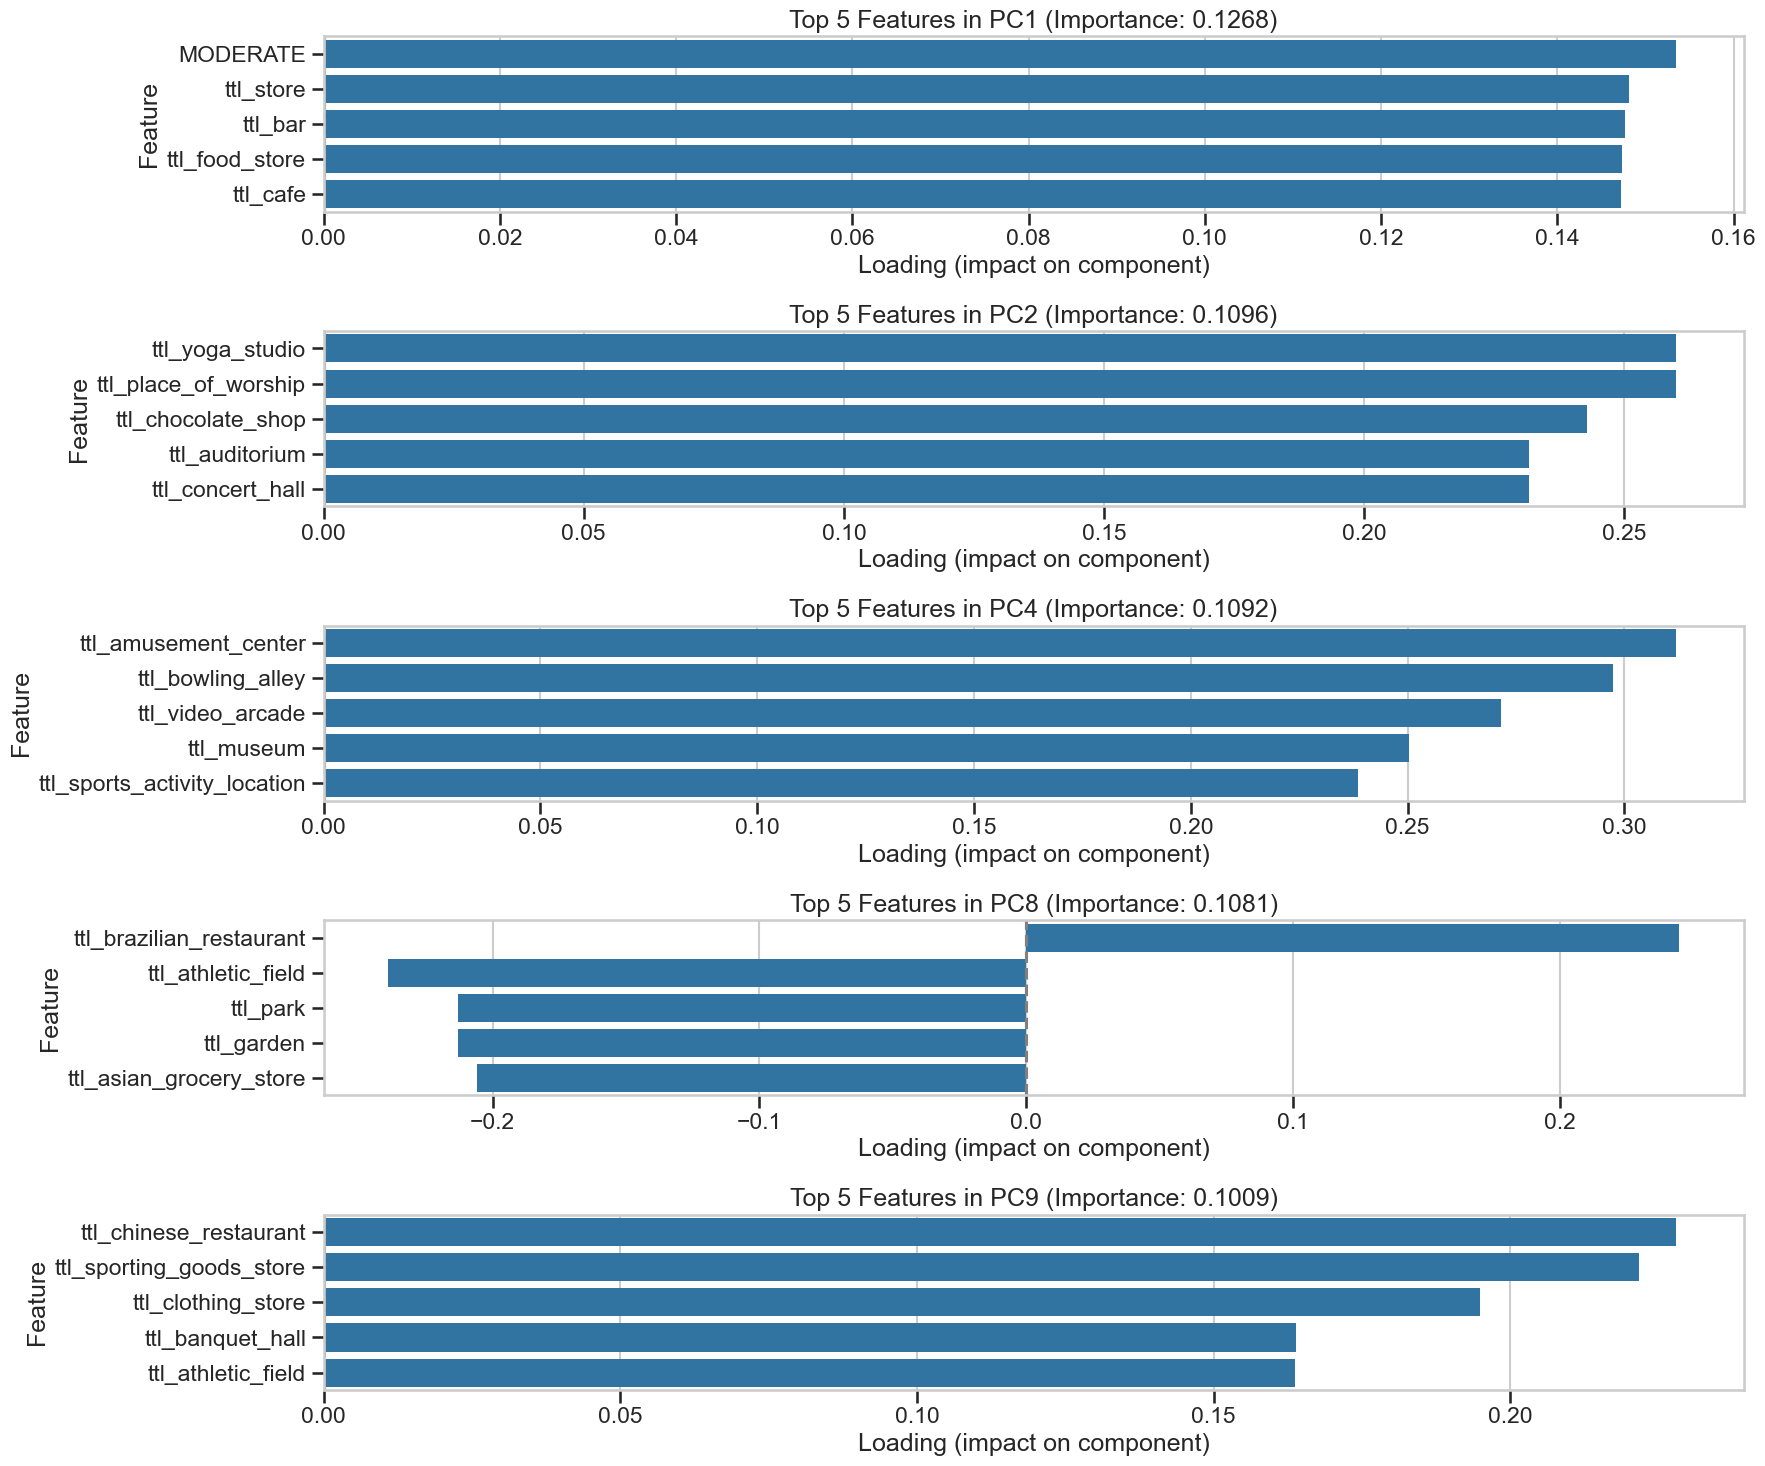


Top 5 features for each important component:

PC1 (Importance: 0.1268):
  MODERATE: 0.1535
  ttl_store: 0.1482
  ttl_bar: 0.1477
  ttl_food_store: 0.1474
  ttl_cafe: 0.1473

PC2 (Importance: 0.1096):
  ttl_yoga_studio: 0.2599
  ttl_place_of_worship: 0.2599
  ttl_chocolate_shop: 0.2428
  ttl_auditorium: 0.2318
  ttl_concert_hall: 0.2318

PC4 (Importance: 0.1092):
  ttl_amusement_center: 0.3119
  ttl_bowling_alley: 0.2973
  ttl_video_arcade: 0.2716
  ttl_museum: 0.2503
  ttl_sports_activity_location: 0.2386

PC8 (Importance: 0.1081):
  ttl_brazilian_restaurant: 0.2446
  ttl_athletic_field: -0.2392
  ttl_park: -0.2131
  ttl_garden: -0.2131
  ttl_asian_grocery_store: -0.2058

PC9 (Importance: 0.1009):
  ttl_chinese_restaurant: 0.2279
  ttl_sporting_goods_store: 0.2217
  ttl_clothing_store: 0.1949
  ttl_banquet_hall: 0.1639
  ttl_athletic_field: 0.1637

PC1 explains 31.35% of total variance

PC2 explains 7.05% of total variance

PC4 explains 4.23% of total variance

PC8 explains 2.64% of t

In [33]:
# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Perform PCA
n_components = 10  # Choose a reasonable number of components
pca = PCA(n_components=n_components)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

# Train Random Forest on PCA components
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_pca, y_train)

# Get component importance in the Random Forest model
component_importance = pd.DataFrame({
    'Component': [f'PC{i+1}' for i in range(n_components)],
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("Component importance in Random Forest model:")
print(component_importance.head(5))

# Get loadings for each component
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f'PC{i+1}' for i in range(n_components)],
    index=all_features
)

# For the top 5 important components, show the top 5 features
top_components = component_importance.head(5)['Component'].values

plt.figure(figsize=(18, 15))
for i, component in enumerate(top_components):
    plt.subplot(5, 1, i+1)
    
    # Get absolute loadings for this component
    component_loadings = loadings[component].abs().sort_values(ascending=False)
    top_features = component_loadings.head(5).index
    
    # Show actual loadings (not absolute)
    top_feature_loadings = loadings.loc[top_features, component]
    
    # Plot
    sns.barplot(x=top_feature_loadings, y=top_features)
    plt.title(f'Top 5 Features in {component} (Importance: {rf_model.feature_importances_[int(component[2:])-1]:.4f})')
    plt.xlabel('Loading (impact on component)')
    plt.ylabel('Feature')
    plt.axvline(x=0, color='gray', linestyle='--')
    
plt.tight_layout()
plt.show()

# Create a summary table
summary_data = []
for component in top_components:
    component_loadings = loadings[component].abs().sort_values(ascending=False)
    top_features = component_loadings.head(5).index
    
    # Get actual loadings (not absolute)
    top_feature_loadings = loadings.loc[top_features, component]
    
    for feature, loading in zip(top_features, top_feature_loadings):
        summary_data.append({
            'Component': component,
            'Importance': rf_model.feature_importances_[int(component[2:])-1],
            'Feature': feature,
            'Loading': loading
        })

summary_df = pd.DataFrame(summary_data)
print("\nTop 5 features for each important component:")
for component in top_components:
    print(f"\n{component} (Importance: {rf_model.feature_importances_[int(component[2:])-1]:.4f}):")
    component_features = summary_df[summary_df['Component'] == component]
    for _, row in component_features.iterrows():
        print(f"  {row['Feature']}: {row['Loading']:.4f}")

# Calculate explained variance for each component
explained_variance = pca.explained_variance_ratio_

# Add explained variance to the summary
for i, component in enumerate(top_components):
    print(f"\n{component} explains {explained_variance[int(component[2:])-1]:.2%} of total variance")